<a href="https://colab.research.google.com/github/HoniTahina/-arene-des-algos-Tahina-HONI-RIKA/blob/main/J4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Phase 0 — Installation & imports
!pip install -q flask flask-ngrok pyngrok streamlit joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                              f1_score, accuracy_score, roc_auc_score)
import joblib
import time

# Chargement du dataset
data = load_breast_cancer()
X, y = data.data, data.target

print(f"Dataset : {X.shape[0]} lignes, {X.shape[1]} features")
print(f"Classes : {data.target_names}")
print(f"Répartition : {np.bincount(y)} → {np.bincount(y)/len(y)*100}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 40.6 MB/s eta 0:00:00
Dataset : 569 lignes, 30 features
Classes : ['malignant' 'benign']
Répartition : [212 357] → [37.25834798 62.74165202]


In [2]:
# Phase 1 — Fonction de split

def split_train_val_test(X, y, test_size=0.2, val_size=0.2, random_state=42):
    """
    Découpe X, y en trois jeux : train, validation, test.
    Renvoie 6 objets : X_train, X_val, X_test, y_train, y_val, y_test.
    Les proportions sont respectées avec stratify=y.
    """
    if val_size <= 0 or val_size >= 1:
        raise ValueError(f"val_size doit être entre 0 et 1 (reçu : {val_size})")
    if test_size <= 0 or test_size >= 1:
        raise ValueError(f"test_size doit être entre 0 et 1 (reçu : {test_size})")

    # Premier split : isoler le test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Recalculer la proportion val sur le reste
    val_size_adjusted = val_size / (1 - test_size)

    # Deuxième split : isoler la validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size_adjusted, random_state=random_state, stratify=y_temp
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


# --- Test normal ---
X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(X, y)
print(f"Train : {len(X_train)} | Validation : {len(X_val)} | Test : {len(X_test)}")
print(f"Total : {len(X_train)+len(X_val)+len(X_test)} == {len(X)} → {len(X_train)+len(X_val)+len(X_test)==len(X)}")

def check_stratification(y_full, y_train, y_val, y_test):
    ref = np.bincount(y_full) / len(y_full)
    for name, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
        ratio = np.bincount(yy) / len(yy)
        ok = np.allclose(ref, ratio, atol=0.05)
        print(f"  {name} → {ratio.round(2)} {'✓' if ok else '✗'}")

print("Répartition des classes conservée dans chaque jeu :")
check_stratification(y, y_train, y_val, y_test)

# --- Test cas limite : val_size=0 ---
print("\n--- Cas limite : val_size=0 ---")
try:
    split_train_val_test(X, y, val_size=0)
    print("PROBLÈME : la fonction n'a pas planté !")
except ValueError as e:
    print(f"Erreur propre capturée : {e}")

# --- Test cas adversarial : dataset déséquilibré 95/5 ---
print("\n--- Cas adversarial : dataset 95/5 ---")
np.random.seed(42)
n = 500
X_imb = np.random.randn(n, 5)
y_imb = np.array([0]*475 + [1]*25)

Xtr, Xv, Xte, ytr, yv, yte = split_train_val_test(X_imb, y_imb)
print("Répartition dans chaque jeu (doit rester ~95/5) :")
check_stratification(y_imb, ytr, yv, yte)

Train : 341 | Validation : 114 | Test : 114
Total : 569 == 569 → True
Répartition des classes conservée dans chaque jeu :
  Train → [0.37 0.63] ✓
  Val → [0.38 0.62] ✓
  Test → [0.37 0.63] ✓

--- Cas limite : val_size=0 ---
Erreur propre capturée : val_size doit être entre 0 et 1 (reçu : 0)

--- Cas adversarial : dataset 95/5 ---
Répartition dans chaque jeu (doit rester ~95/5) :
  Train → [0.95 0.05] ✓
  Val → [0.95 0.05] ✓
  Test → [0.95 0.05] ✓


In [4]:
# Phase 2 — Bootstrap scores

def bootstrap_scores(modele, X, y, n_iterations=30, random_state=42):
    """
    Évalue la stabilité d'un modèle par bootstrap.
    Tire des échantillons AVEC REMISE, évalue sur les points out-of-bag.
    """
    rng = np.random.default_rng(random_state)
    scores = []
    n = len(X)

    for i in range(n_iterations):
        # Tirage avec remise
        indices_bootstrap = rng.choice(n, size=n, replace=True)
        # Points jamais tirés (out-of-bag)
        indices_oob = np.array(list(set(range(n)) - set(indices_bootstrap)))

        if len(indices_oob) == 0:
            print(f"  Itération {i} : OOB vide, ignorée.")
            continue

        X_boot, y_boot = X[indices_bootstrap], y[indices_bootstrap]
        X_oob, y_oob   = X[indices_oob], y[indices_oob]

        modele.fit(X_boot, y_boot)
        score = modele.score(X_oob, y_oob)
        scores.append(score)

    if len(scores) == 0:
        print("Aucun score calculé (tous les OOB étaient vides).")
        return scores

    moyenne = np.mean(scores)
    ecart   = np.std(scores)

    if len(scores) == 1:
        print(f"Score sur 1 bootstrap : {moyenne:.3f} (écart-type non calculable avec 1 itération)")
    else:
        print(f"Score moyen sur {len(scores)} bootstraps : {moyenne:.3f} (± {ecart:.3f})")

    return scores


# Préparer un modèle
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
modele_lr = LogisticRegression(max_iter=1000, random_state=42)

# --- Test normal ---
print("=== Test normal (30 itérations, avec remise) ===")
scores_with = bootstrap_scores(modele_lr, X_scaled, y, n_iterations=30)

# --- Comparaison SANS remise (faux bootstrap) ---
print("\n=== Comparaison SANS remise (shuffle simple) ===")
def bootstrap_scores_sans_remise(modele, X, y, n_iterations=30, random_state=42):
    rng = np.random.default_rng(random_state)
    scores = []
    n = len(X)
    for i in range(n_iterations):
        indices = rng.choice(n, size=n, replace=False)
        split = int(0.8 * n)
        X_b, y_b = X[indices[:split]], y[indices[:split]]
        X_o, y_o = X[indices[split:]], y[indices[split:]]
        modele.fit(X_b, y_b)
        scores.append(modele.score(X_o, y_o))
    print(f"Score moyen sans remise : {np.mean(scores):.3f} (± {np.std(scores):.3f})")
    return scores

scores_without = bootstrap_scores_sans_remise(modele_lr, X_scaled, y, n_iterations=30)
print(f"\n→ Écart-type AVEC remise : {np.std(scores_with):.4f}")
print(f"→ Écart-type SANS remise : {np.std(scores_without):.4f}")
print("  (avec remise = plus de variabilité, plus honnête sur la stabilité)")

# --- n_iterations=1 ---
print("\n=== Test n_iterations=1 ===")
scores_1 = bootstrap_scores(modele_lr, X_scaled, y, n_iterations=1)

=== Test normal (30 itérations, avec remise) ===
Score moyen sur 30 bootstraps : 0.975 (± 0.010)

=== Comparaison SANS remise (shuffle simple) ===
Score moyen sans remise : 0.978 (± 0.018)

→ Écart-type AVEC remise : 0.0097
→ Écart-type SANS remise : 0.0179
  (avec remise = plus de variabilité, plus honnête sur la stabilité)

=== Test n_iterations=1 ===
Score sur 1 bootstrap : 0.972 (écart-type non calculable avec 1 itération)


In [7]:
# Phase 3 — Validation croisée

def evaluer_en_cross_val(modele, X, y, k=5, stratified=False):
    """
    Lance une validation croisée k-fold et résume les résultats.
    """
    if stratified:
        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    else:
        cv = k

    scores = cross_val_score(modele, X, y, cv=cv, scoring="accuracy")

    print(f"Scores par fold : {scores.round(3)}")
    print(f"Moyenne : {scores.mean():.3f} | Écart-type : {scores.std():.3f}", end=" → ")

    if scores.std() < 0.02:
        print("modèle stable ✓")
    elif scores.std() < 0.05:
        print("légère instabilité, à surveiller ⚠")
    else:
        print("modèle instable, investiguer ✗")

    return scores


# --- Cas normal : k=5 ---
print("=== k=5 (cas normal) ===")
modele_rf = RandomForestClassifier(n_estimators=100, random_state=42)
scores_5 = evaluer_en_cross_val(modele_rf, X_scaled, y, k=5)

# --- Cas limite : Leave-One-Out ---
print("\n=== Leave-One-Out (k = n_samples) ===")
print("⚠ Peut être lent (569 itérations)...")
t0 = time.time()
scores_loo = evaluer_en_cross_val(modele_rf, X_scaled, y, k=len(X))
print(f"Temps LOO : {time.time()-t0:.1f}s")
print("→ Lent car on entraîne autant de modèles que de points de données.")

# --- Cas adversarial : standard vs stratified sur dataset déséquilibré ---
print("\n=== Comparaison standard vs StratifiedKFold sur dataset 95/5 ===")
X_imb_s = scaler.fit_transform(X_imb)
print("Standard :")
scores_std = evaluer_en_cross_val(LogisticRegression(max_iter=1000), X_imb_s, y_imb, k=5, stratified=False)
print("Stratified :")
scores_str = evaluer_en_cross_val(LogisticRegression(max_iter=1000), X_imb_s, y_imb, k=5, stratified=True)
print(f"\n→ Différence de moyenne : {abs(scores_std.mean()-scores_str.mean()):.4f}")

# Visualisation
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), scores_5, color='#378ADD', alpha=0.8, edgecolor='white')
plt.axhline(scores_5.mean(), color='#185FA5', linestyle='--', label=f'Moyenne {scores_5.mean():.3f}')
plt.ylim(0.85, 1.0); plt.xlabel("Fold"); plt.ylabel("Accuracy")
plt.title("Scores par fold — Random Forest, k=5")
plt.xticks(range(1,6)); plt.legend(); plt.show()

=== k=5 (cas normal) ===
Scores par fold : [0.921 0.939 0.982 0.965 0.973]
Moyenne : 0.956 | Écart-type : 0.023 → légère instabilité, à surveiller ⚠

=== Leave-One-Out (k = n_samples) ===
⚠ Peut être lent (569 itérations)...


ValueError: n_splits=569 cannot be greater than the number of members in each class.

=== k=5 (cas normal) ===
Scores par fold : [0.921 0.939 0.982 0.965 0.973]
Moyenne : 0.956 | Écart-type : 0.023 → légère instabilité, à surveiller ⚠

=== Leave-One-Out (k = n_samples) ===
⚠ Peut être lent (569 itérations)...
Scores par fold : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 0. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1.

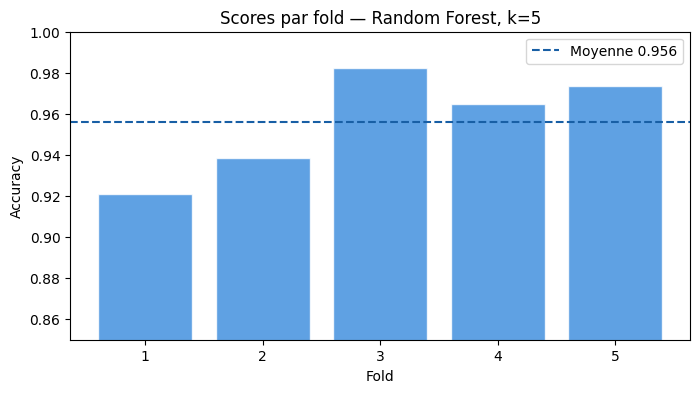

In [8]:
from sklearn.model_selection import LeaveOneOut

def evaluer_en_cross_val(modele, X, y, k=5, stratified=False):
    """
    Lance une validation croisée k-fold et résume les résultats.
    """
    if k == len(X): # Pour Leave-One-Out
        cv = LeaveOneOut()
    elif stratified:
        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    else:
        cv = k

    scores = cross_val_score(modele, X, y, cv=cv, scoring="accuracy")

    print(f"Scores par fold : {scores.round(3)}")
    print(f"Moyenne : {scores.mean():.3f} | Écart-type : {scores.std():.3f}", end=" → ")

    if scores.std() < 0.02:
        print("modèle stable ✓")
    elif scores.std() < 0.05:
        print("légère instabilité, à surveiller ⚠")
    else:
        print("modèle instable, investiguer ✗")

    return scores


# --- Cas normal : k=5 ---
print("=== k=5 (cas normal) ===")
modele_rf = RandomForestClassifier(n_estimators=100, random_state=42)
scores_5 = evaluer_en_cross_val(modele_rf, X_scaled, y, k=5)

# --- Cas limite : Leave-One-Out ---
print("\n=== Leave-One-Out (k = n_samples) ===")
print("⚠ Peut être lent (569 itérations)...")
t0 = time.time()
scores_loo = evaluer_en_cross_val(modele_rf, X_scaled, y, k=len(X))
print(f"Temps LOO : {time.time()-t0:.1f}s")
print("→ Lent car on entraîne autant de modèles que de points de données.")

# --- Cas adversarial : standard vs stratified sur dataset déséquilibré ---
print("\n=== Comparaison standard vs StratifiedKFold sur dataset 95/5 ===")
X_imb_s = scaler.fit_transform(X_imb)
print("Standard :")
scores_std = evaluer_en_cross_val(LogisticRegression(max_iter=1000), X_imb_s, y_imb, k=5, stratified=False)
print("Stratified :")
scores_str = evaluer_en_cross_val(LogisticRegression(max_iter=1000), X_imb_s, y_imb, k=5, stratified=True)
print(f"\n→ Différence de moyenne : {abs(scores_std.mean()-scores_str.mean()):.4f}")

# Visualisation
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), scores_5, color='#378ADD', alpha=0.8, edgecolor='white')
plt.axhline(scores_5.mean(), color='#185FA5', linestyle='--', label=f'Moyenne {scores_5.mean():.3f}')
plt.ylim(0.85, 1.0); plt.xlabel("Fold"); plt.ylabel("Accuracy")
plt.title("Scores par fold — Random Forest, k=5")
plt.xticks(range(1,6)); plt.legend(); plt.show()